### El perceptrón XOR

In [7]:
## Importaciones 
import sys, os
sys.path.append(os.path.abspath('..'))
from michigrad.engine import Value
from michigrad.visualize import show_graph
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Definimos nuestras variables de entradas y las salidas deseadas

x00 = Value(0., name='x0=0')
x01 = Value(1., name='x0=1')
x10 = Value(0., name='x1=0')
x11 = Value(1., name='x1=1')

y0 = Value(0., name='y=0')
y1 = Value(1., name='y=1')


In [9]:
# Definimos la funcion de activacion, en este caso vamos a usar la funcion swish
def swish(x: Value, beta=1.0):
    return x * (1 / (1 + (-beta * x).exp()))

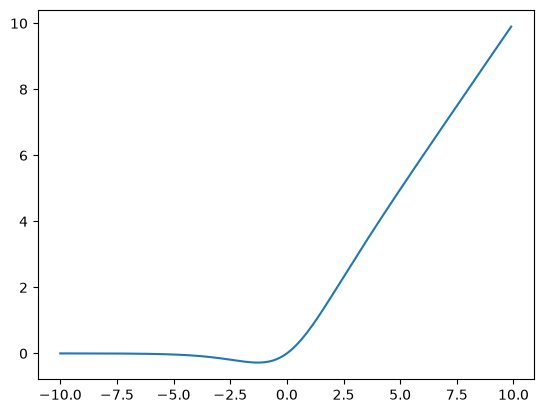

In [10]:
# mostrar el grafico de la función
x = np.arange(-10, 10, 0.1) # De 5 a 5 avanzado a 0,1 pasos
s = []
for i in x:
    s.append(swish(Value(i)).data) #Data lo usamos para plotearlo
    
plt.plot(x, s)

In [11]:
# Ahora vamos a definir los pesos para nuestro perceptron y tambien lo haremos con el sesgo
np.random.seed(42)
w0 = Value(np.random.random(), name='w0')
w1 = Value(np.random.random(), name='w1')
b = Value(np.random.random(), name='bias')

A partir de ahora lo que vamos a hacer es una primera corrida del modelo para despues ver como hacer el ajuste para entrenar al perceptron

In [ ]:
# Primero hacemos el forward pass 
swish(x00*w0 + x11*w1 + b)

Value(data=0.8432628148712872, grad=0, name=)

In [13]:
yhat00 = swish(x00*w0 + x10*w1 + b)
yhat01 = swish(x00*w0 + x11*w1 + b)
yhat10 = swish(x01*w0 + x10*w1 + b)
yhat11 = swish(x01*w0 + x11*w1 + b)

print(yhat00, yhat01, yhat10, yhat11)

Value(data=0.49427354865917544, grad=0, name=) Value(data=1.418965294002244, grad=0, name=) Value(data=0.8315408590925021, grad=0, name=) Value(data=1.82411682545248, grad=0, name=)


Vemos que los resultados se acercan un poco ya a lo que nosotros queremos pero primero analizaremos el L y luego ajustaremos para que el modelo mejore

In [14]:
# Calculamos la Lost Function
L = ((y0-yhat00)**2 + (y1-yhat01)**2 + (y1-yhat10)**2 + (y0 - yhat11)**2)/4
L.name = 'L'
L

Value(data=0.9439047333841617, grad=0, name=L)

Ya esta cercano a 0 pero aun se puede mejorar

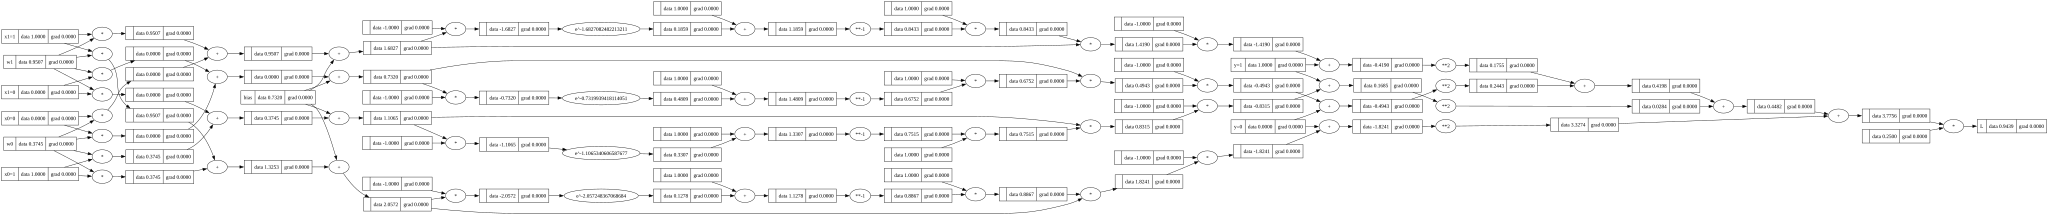

In [15]:
# Veamos el grafo de operaciones para luego aplicar el Backpropagtion
show_graph(L)


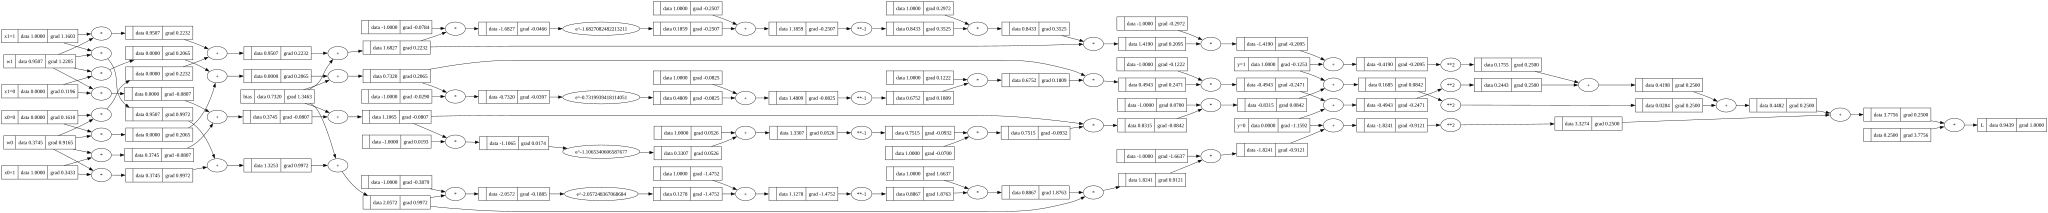

In [16]:
# Aplicamos Backpropagation para calcular los gradientes de los pesos y el sesgo y segun lo que veamos, aplicaremos el ajuste correspondiente
L.backward()
show_graph(L)

Preguntar que hacer cuando el gradiente da 0

In [20]:
# Ahora aplicamos el training loop para que el modelo sepa resolver
for i in range(10000):
    # Forward pass
    yhat00 = swish(x00*w0 + x10*w1 + b)
    yhat00.name = 'y00'
    yhat01 = swish(x00*w0 + x11*w1 + b)
    yhat01.name = 'y01'
    yhat10 = swish(x01*w0 + x10*w1 + b)
    yhat10.name = 'y10'
    yhat11 = swish(x01*w0 + x11*w1 + b) # Forward pass -> Ejecutar el modelo
    yhat11.name = 'y11'
    # Lost Function
    L = ((y0-yhat00)**2 + (y1-yhat01)**2 + (y1-yhat10)**2 + (y0 - yhat11)**2)/4 # Calcular la funcion de perdida
    L.name = 'L'
    # Zero Grad
    w0.grad = 0 # Poner todos los gradiente de la corrida en 0
    w1.grad = 0
    b.grad = 0
    # Backpropagation
    L.backward() # Aplicar el algoritmo de backpropagation en el grafo de operaciones
    # Realizar el update. Es decir, movernos en la direccion contraria al gradiente
    # el cual se suele multiplicar por un valor muy chiquito. Esto ultimo se llama learning rate que seria que tan brusco es el cambio de W
    w0.data -= w0.grad * 0.1
    w1.data -= w1.grad * 0.1
    b.data -= b.grad * 0.1
    print(L.data)

0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997
0.24999999999999997


In [21]:
# Probamos el modelo
swish(0 * w0 + 1*w1 + b)

Value(data=0.4999999999999998, grad=0, name=)

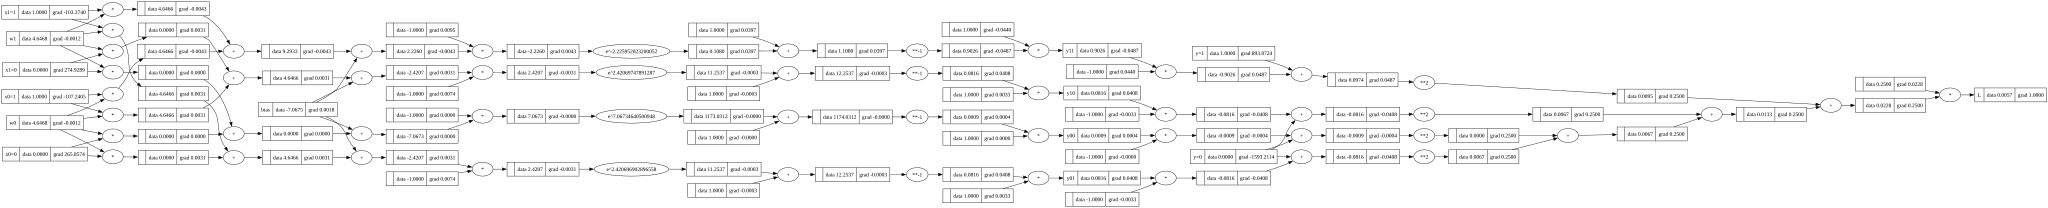

In [111]:
show_graph(L)